# Exploratory Data Analysis — Ames Housing (train.csv)
### Focus: Machine Learning readiness (distributions, scale, normality, correlations, missingness)

**Goal:** Understand the dataset well enough to design a solid preprocessing pipeline for a regression model
predicting `SalePrice`. We specifically check:

1. Overall data quality (shape, dtypes, duplicates, missing values)
2. The target variable's distribution and normality (relevant for linear models / RMSE-on-log metrics)
3. Numerical feature distributions, skewness, and **scale** differences (relevant for gradient-based / distance-based models)
4. Categorical feature cardinality and relationship with the target
5. Correlations and multicollinearity
6. Outliers
7. A final **concluding preprocessing summary**

Dataset: 1,022 houses, 81 columns (79 explanatory + `Id` + `SalePrice`). Source: Ames Housing dataset.


## 1. Setup & Data Loading

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display / plotting configuration
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12

RANDOM_STATE = 42


ModuleNotFoundError: No module named 'numpy'

In [2]:
df = pd.read_csv('train.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 1022 rows x 81 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,101041,160,FV,24.0,2645,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,Twnhs,2Story,8,5,1999,2000,Gable,CompShg,MetalSd,MetalSd,BrkFace,456.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,776,776,GasA,Ex,Y,SBrkr,764,677,0,1441,0,0,2,1,2,1,Gd,5,Typ,0,NaN,Detchd,1999.0,Unf,2,492,TA,TA,Y,206,0,0,0,0,0,NaN,NaN,NaN,0,11,2007,WD,Normal,174000
1,100674,60,RL,65.0,8461,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,6,5,2005,2006,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,728,728,GasA,Ex,Y,SBrkr,728,728,0,1456,0,0,2,1,3,1,Gd,8,Typ,1,Gd,Attchd,2005.0,Fin,2,390,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,7,2006,New,Partial,163990
2,100655,90,RM,60.0,7200,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,Duplex,SFoyer,5,5,1980,1980,Gable,CompShg,MetalSd,MetalSd,BrkFace,180.0,TA,TA,CBlock,Gd,TA,Gd,GLQ,936,Unf,0,0,936,GasA,TA,Y,SBrkr,936,0,0,936,1,0,1,0,2,1,TA,4,Typ,0,NaN,Detchd,1980.0,Unf,2,672,TA,TA,Y,49,0,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,140000
3,100374,20,RL,75.0,9986,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2006,2007,Gable,CompShg,VinylSd,VinylSd,BrkFace,428.0,Gd,TA,PConc,Ex,TA,Av,Unf,0,Unf,0,1795,1795,GasA,Ex,Y,SBrkr,1795,0,0,1795,0,0,2,0,2,1,Gd,7,Typ,1,Gd,Attchd,2007.0,RFn,3,895,TA,TA,Y,0,49,0,0,0,0,NaN,NaN,NaN,0,2,2007,New,Partial,147000
4,101223,50,RL,60.0,9120,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,Norm,1Fam,1.5Fin,7,6,1925,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,Gd,PConc,TA,TA,No,Rec,329,Unf,0,697,1026,GasA,Ex,Y,SBrkr,1133,687,0,1820,1,0,2,0,4,1,TA,8,Typ,0,NaN,Detchd,1925.0,Unf,1,240,TA,TA,N,0,100,0,0,0,0,NaN,GdPrv,NaN,0,6,2008,WD,Normal,184000


In [3]:
# Basic structural info: dtypes and non-null counts
df.info(verbose=True, memory_usage='deep')


<class 'pandas.DataFrame'>
RangeIndex: 1022 entries, 0 to 1021
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1022 non-null   int64  
 1   MSSubClass     1022 non-null   int64  
 2   MSZoning       1022 non-null   str    
 3   LotFrontage    836 non-null    float64
 4   LotArea        1022 non-null   int64  
 5   Street         1022 non-null   str    
 6   Alley          72 non-null     str    
 7   LotShape       1022 non-null   str    
 8   LandContour    1022 non-null   str    
 9   Utilities      1022 non-null   str    
 10  LotConfig      1022 non-null   str    
 11  LandSlope      1022 non-null   str    
 12  Neighborhood   1022 non-null   str    
 13  Condition1     1022 non-null   str    
 14  Condition2     1022 non-null   str    
 15  BldgType       1022 non-null   str    
 16  HouseStyle     1022 non-null   str    
 17  OverallQual    1022 non-null   int64  
 18  OverallCond    1022

**Note on dtypes:** many columns encoded as numbers are actually *categorical* by definition
(e.g. `MSSubClass` is a dwelling-type code, not a continuous quantity). We flag this explicitly below,
because feeding ordinal-looking codes into a model as raw integers can silently introduce a false
numeric relationship (e.g. implying `MSSubClass=190` is "more" than `MSSubClass=20`).


In [4]:
# Columns that are numeric in dtype but categorical (nominal) in meaning, per data_description.txt
NUMERIC_BUT_CATEGORICAL = ['MSSubClass']  # MoSold / YrSold are kept numeric but treated carefully later

print("Flagged as pseudo-numeric (should be treated as categorical):")
for c in NUMERIC_BUT_CATEGORICAL:
    print(f" - {c}: {df[c].nunique()} unique codes ->", sorted(df[c].unique())[:6], '...')


Flagged as pseudo-numeric (should be treated as categorical):
 - MSSubClass: 15 unique codes -> [np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60)] ...


## 2. Data Quality Checks

Before looking at distributions, we check the basics: duplicate rows, an identifier column that
must be excluded from modeling, and missing values (which in this dataset are often **meaningful**,
not random — e.g. `NaN` in `PoolQC` means "no pool", not "unknown").


In [5]:
# Id column: unique identifier, must never be used as a predictive feature
print("Id is unique for every row:", df['Id'].is_unique)

# Duplicate rows (excluding Id)
n_dupes = df.drop(columns=['Id']).duplicated().sum()
print(f"Fully duplicated rows (ignoring Id): {n_dupes}")


Id is unique for every row: True
Fully duplicated rows (ignoring Id): 0


In [6]:
# Missing values overview
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
missing_df


,n_missing,pct_missing
PoolQC,1015,99.3
MiscFeature,985,96.4
Alley,950,93.0
Fence,822,80.4
MasVnrType,612,59.9
FireplaceQu,486,47.6
LotFrontage,186,18.2
GarageType,50,4.9
GarageYrBlt,50,4.9
GarageFinish,50,4.9


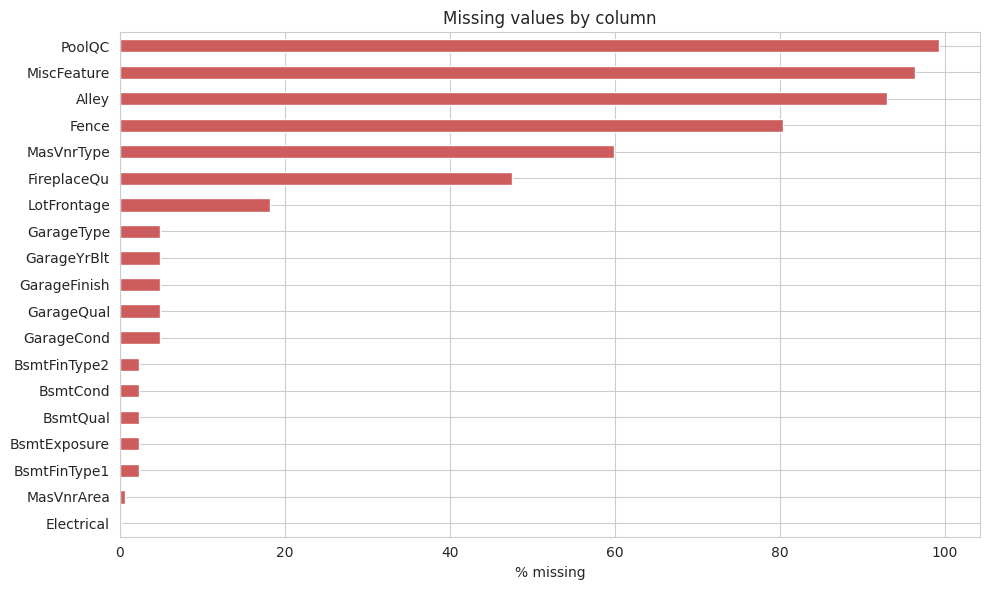

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_df['pct_missing'].plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel('% missing')
ax.set_title('Missing values by column')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Key insight (cross-checked against `data_description.txt`):** for most of the highest-missing
columns, `NaN` is not "unknown data" but an explicit category meaning the feature is **absent**:

| Column | NaN meaning |
|---|---|
| `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu` | No pool / no misc feature / no alley / no fence / no fireplace |
| `Garage*` (Type, Finish, Qual, Cond, YrBlt) | No garage |
| `Bsmt*` (Qual, Cond, Exposure, FinType1/2) | No basement |
| `MasVnrType` / `MasVnrArea` | No masonry veneer |

This means **imputing these with the column mean/mode would be wrong** — the correct treatment is:
- Categorical: fill with an explicit `"None"` category.
- Numeric (`MasVnrArea`, `GarageYrBlt`): fill with `0` (or a sentinel), not the mean.

`LotFrontage` (~18% missing) and `Electrical` (1 row) are the only columns where missingness looks
like genuinely missing data rather than "feature absent" — these are better candidates for
group-wise median imputation (e.g. median `LotFrontage` per `Neighborhood`).


## 3. Target Variable: `SalePrice`

This is the most important variable to understand. Many regression models (linear regression, Ridge/Lasso,
and the RMSE-on-log-price metric commonly used for this dataset) perform much better when the target is
**approximately normally distributed**. We check for skewness and consider a log transform.


In [8]:
print(df['SalePrice'].describe())
print(f"\nSkewness: {df['SalePrice'].skew():.3f}")
print(f"Kurtosis: {df['SalePrice'].kurt():.3f}")


count      1022.000000
mean     180927.609589
std       79582.721642
min       35311.000000
25%      130000.000000
50%      163000.000000
75%      214375.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.950
Kurtosis: 7.352


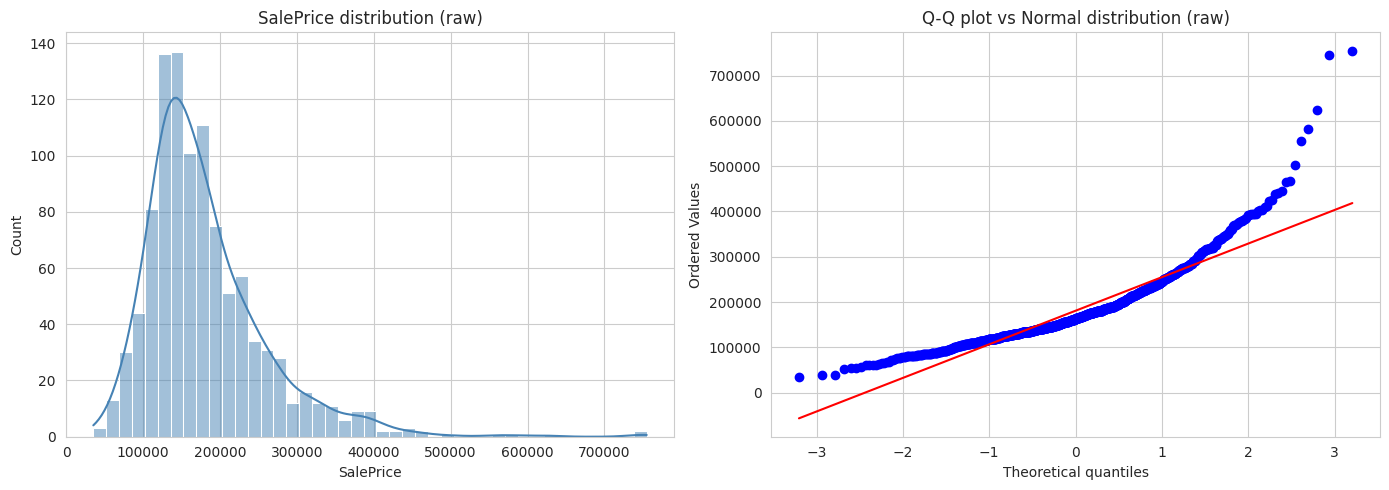

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice distribution (raw)')

stats.probplot(df['SalePrice'], plot=axes[1])
axes[1].set_title('Q-Q plot vs Normal distribution (raw)')

plt.tight_layout()
plt.show()


The raw target is **right-skewed** (skew > 1) with a heavy right tail (a handful of very expensive
houses) and the Q-Q plot bows away from the reference line at the top end — a clear deviation from
normality. Let's check if a log transform fixes this, since `log(SalePrice)` is the standard choice
for this dataset.


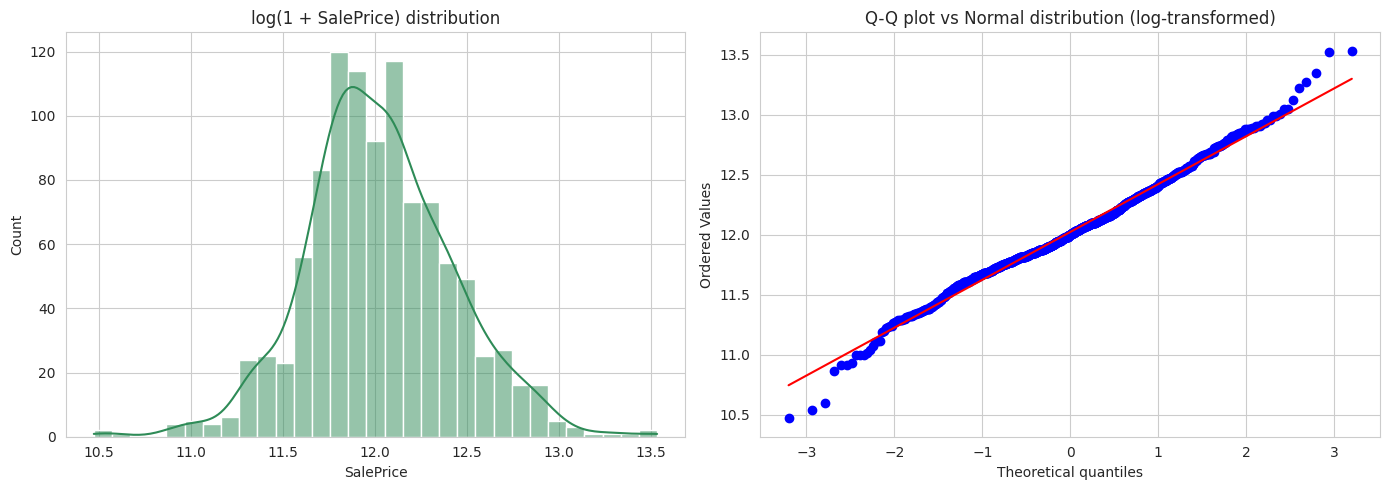

Skewness before: 1.950  ->  after log1p: 0.124


In [10]:
log_price = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(log_price, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('log(1 + SalePrice) distribution')

stats.probplot(log_price, plot=axes[1])
axes[1].set_title('Q-Q plot vs Normal distribution (log-transformed)')

plt.tight_layout()
plt.show()

print(f"Skewness before: {df['SalePrice'].skew():.3f}  ->  after log1p: {log_price.skew():.3f}")


In [11]:
# Formal normality test (Shapiro-Wilk). Note: with n~1000 the test is very sensitive,
# so we treat the statistic (W closer to 1 = more normal) as more informative than the p-value alone.
stat_raw, p_raw = stats.shapiro(df['SalePrice'])
stat_log, p_log = stats.shapiro(log_price)
print(f"Shapiro-Wilk raw SalePrice:      W={stat_raw:.4f}, p={p_raw:.2e}")
print(f"Shapiro-Wilk log(1+SalePrice):   W={stat_log:.4f}, p={p_log:.2e}")


Shapiro-Wilk raw SalePrice:      W=0.8666, p=1.28e-28
Shapiro-Wilk log(1+SalePrice):   W=0.9916, p=1.47e-05


**Conclusion:** `log1p(SalePrice)` is markedly closer to a Gaussian shape (lower skew, straighter
Q-Q line, higher Shapiro W statistic). **Recommendation: train the model on `log1p(SalePrice)`** and
apply `np.expm1()` to predictions before evaluating in original dollars.


## 4. Numerical Features: Distribution, Skewness & Scale

Two separate things matter for ML here:
1. **Shape (skew)** — affects models that assume linearity/normal residuals, and affects tree models less.
2. **Scale (range/units)** — critical for distance-based or gradient-based models (KNN, SVM, linear models with
   regularization, neural nets). Features on very different scales (e.g. `LotArea` in the thousands vs
   `OverallQual` from 1-10) will dominate distance calculations or regularization penalties unless scaled.


In [12]:
# Separate numeric columns, excluding Id, the target, and the pseudo-categorical column
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Id', 'SalePrice'] + NUMERIC_BUT_CATEGORICAL]
print(f"{len(numeric_cols)} numerical features")
numeric_cols


35 numerical features


['LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [13]:
desc = df[numeric_cols].describe().T
desc['range'] = desc['max'] - desc['min']
desc[['min', 'max', 'range', 'mean', 'std']].sort_values('range', ascending=False).head(15)


,min,max,range,mean,std
LotArea,1300.0,215245.0,213945.0,10544.590020,10437.129242
MiscVal,0.0,15500.0,15500.0,51.207436,582.833285
TotalBsmtSF,0.0,6110.0,6110.0,1059.098826,444.011050
BsmtFinSF1,0.0,5644.0,5644.0,447.238748,466.960751
GrLivArea,438.0,5642.0,5204.0,1519.471624,533.197094
1stFlrSF,372.0,4692.0,4320.0,1160.262231,385.877323
BsmtUnfSF,0.0,2153.0,2153.0,564.480431,433.514279
2ndFlrSF,0.0,2065.0,2065.0,353.930528,444.676473
GarageArea,0.0,1418.0,1418.0,476.688845,209.356261
MasVnrArea,0.0,1378.0,1378.0,102.917323,178.603116


The table above already shows the scale problem clearly: `LotArea` ranges over tens of thousands
while `OverallQual`, `FullBath`, etc. range over single digits. **Any model sensitive to feature
magnitude needs these standardized/scaled** (e.g. `StandardScaler` or `RobustScaler`) before training.


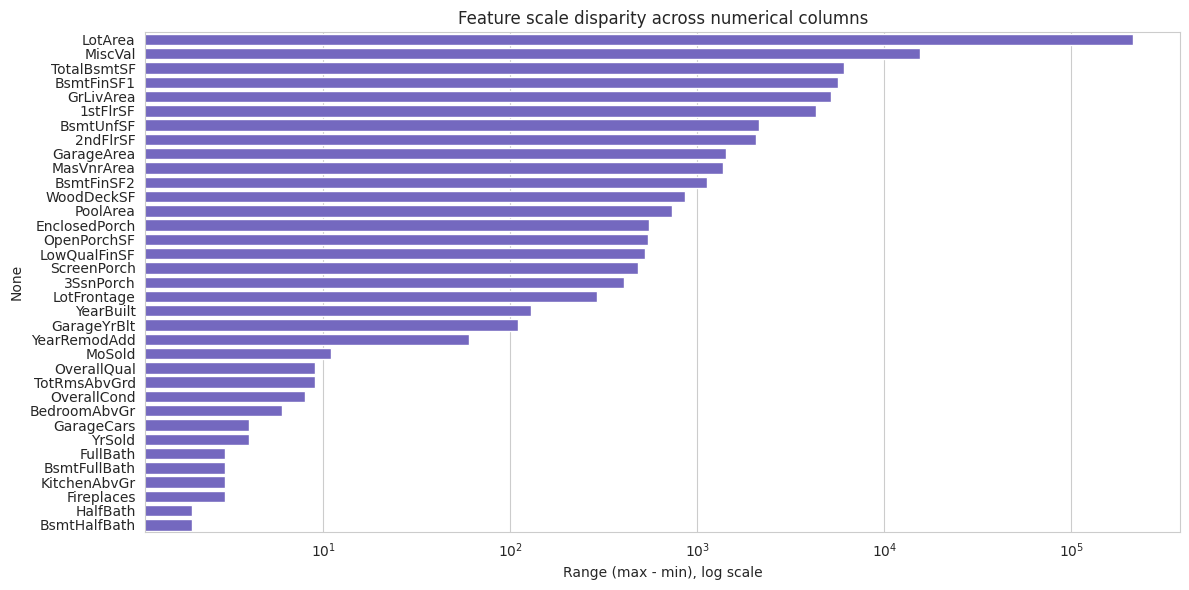

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
# Compare ranges on a log scale to visualize the magnitude disparity across features
ranges = desc['range'].sort_values(ascending=False)
sns.barplot(x=ranges.values, y=ranges.index, ax=ax, color='slateblue')
ax.set_xscale('log')
ax.set_xlabel('Range (max - min), log scale')
ax.set_title('Feature scale disparity across numerical columns')
plt.tight_layout()
plt.show()


In [15]:
# Skewness of every numeric feature, sorted
skewness = df[numeric_cols].skew().sort_values(ascending=False)
skew_df = pd.DataFrame({'skewness': skewness})
skew_df['interpretation'] = pd.cut(
    skew_df['skewness'].abs(),
    bins=[-0.01, 0.5, 1, np.inf],
    labels=['~symmetric', 'moderately skewed', 'highly skewed']
)
skew_df


,skewness,interpretation
MiscVal,21.457822,highly skewed
PoolArea,12.375518,highly skewed
LotArea,12.244710,highly skewed
LowQualFinSF,9.436358,highly skewed
3SsnPorch,8.717241,highly skewed
KitchenAbvGr,4.413000,highly skewed
ScreenPorch,4.243760,highly skewed
BsmtFinSF2,4.058529,highly skewed
BsmtHalfBath,3.973061,highly skewed
EnclosedPorch,3.181552,highly skewed


In [16]:
highly_skewed = skew_df[skew_df['skewness'].abs() > 1].index.tolist()
print(f"{len(highly_skewed)} features are highly skewed (|skew| > 1):")
print(highly_skewed)


18 features are highly skewed (|skew| > 1):
['MiscVal', 'PoolArea', 'LotArea', 'LowQualFinSF', '3SsnPorch', 'KitchenAbvGr', 'ScreenPorch', 'BsmtFinSF2', 'BsmtHalfBath', 'EnclosedPorch', 'LotFrontage', 'MasVnrArea', 'OpenPorchSF', 'BsmtFinSF1', 'TotalBsmtSF', 'WoodDeckSF', 'GrLivArea', '1stFlrSF']


Many of these highly-skewed columns (`PoolArea`, `MiscVal`, `LowQualFinSF`, `3SsnPorch`, ...) are
**sparse "mostly-zero" features** (a pool/porch/etc. that most houses don't have) rather than genuinely
continuous skewed measurements. For these, a log transform mainly helps if the non-zero values themselves
are skewed; for near-constant/mostly-zero columns, consider a binary "has feature" indicator instead.


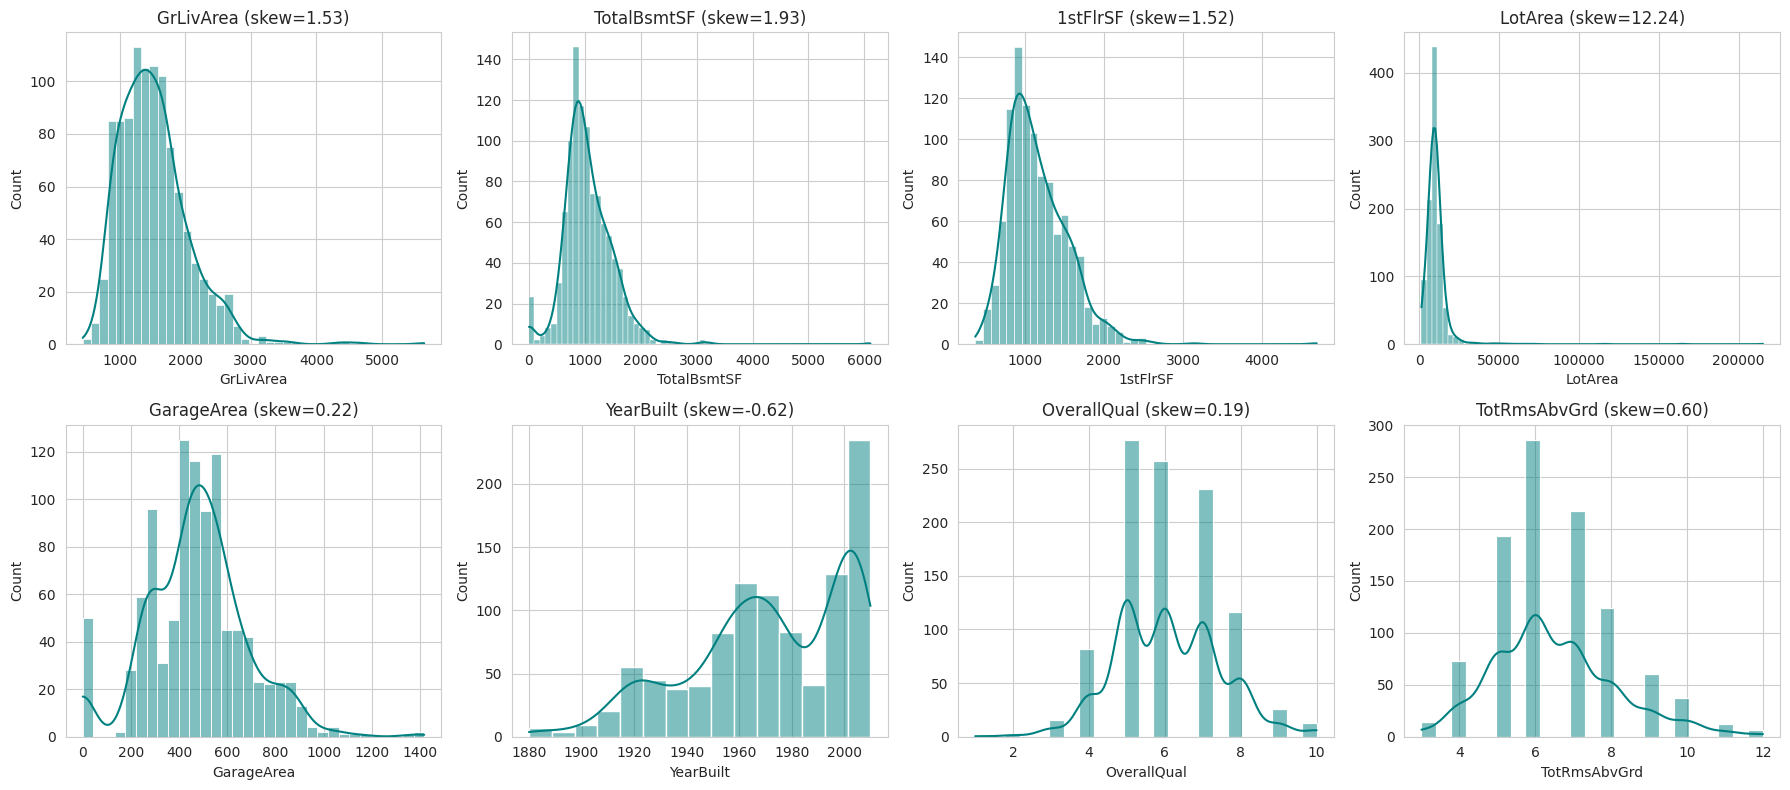

In [17]:
# Distribution grid for the most important continuous numeric features
key_numeric = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'LotArea', 'GarageArea',
               'YearBuilt', 'OverallQual', 'TotRmsAbvGrd']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, key_numeric):
    sns.histplot(df[col], kde=True, ax=ax, color='teal')
    ax.set_title(f"{col} (skew={df[col].skew():.2f})")
plt.tight_layout()
plt.show()


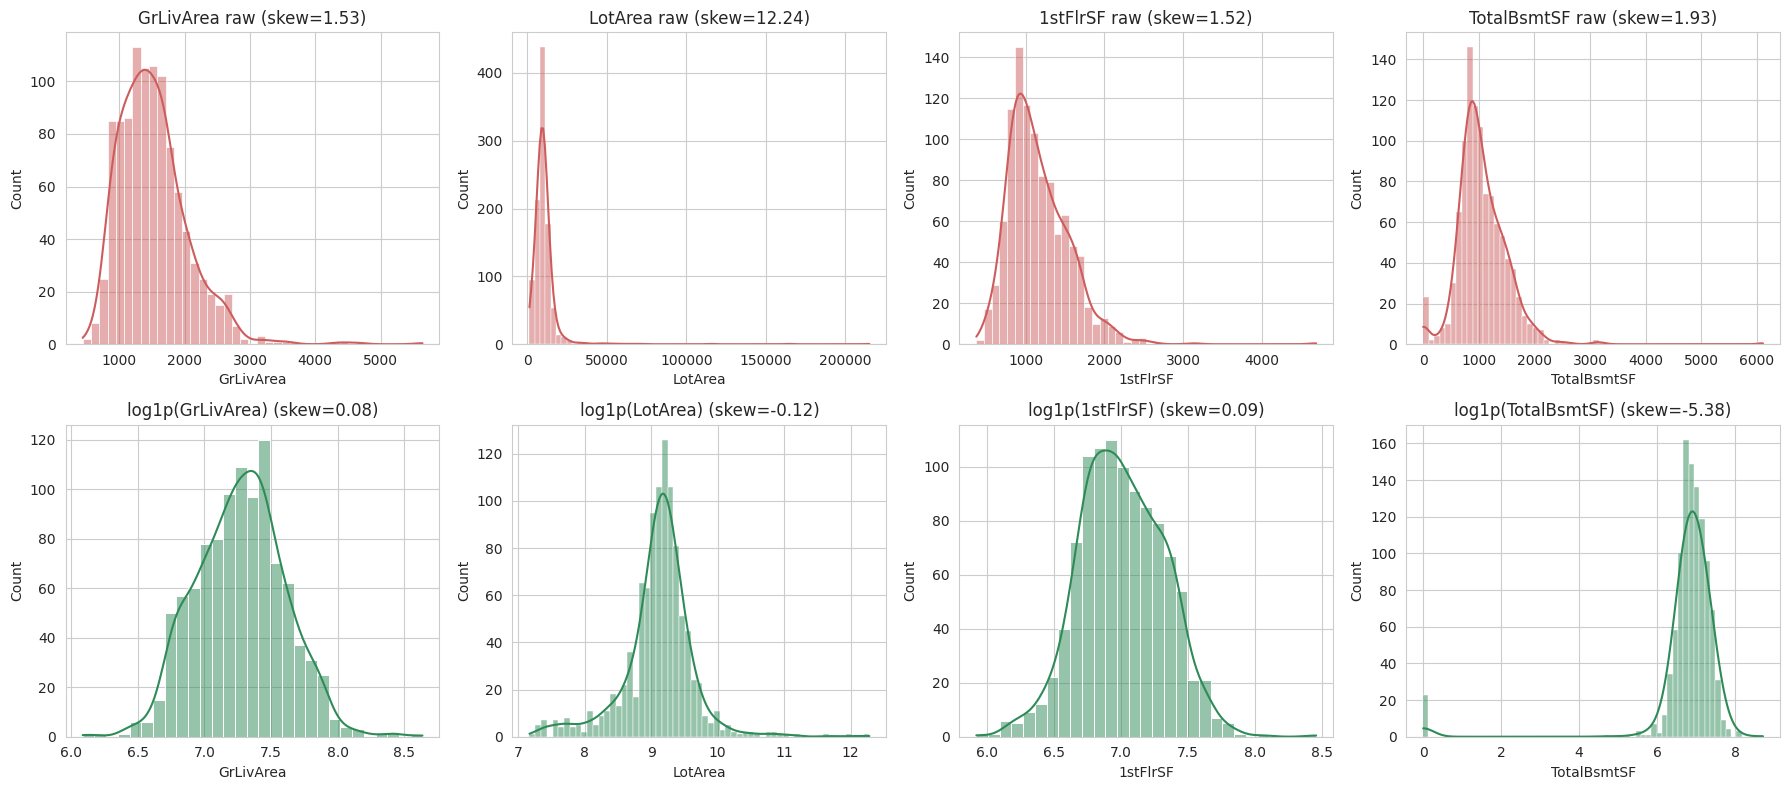

In [18]:
# Effect of log1p on the most skewed *continuous* (non-sparse) features
continuous_skewed = ['GrLivArea', 'LotArea', '1stFlrSF', 'TotalBsmtSF']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(continuous_skewed):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='indianred')
    axes[0, i].set_title(f"{col} raw (skew={df[col].skew():.2f})")

    log_col = np.log1p(df[col])
    sns.histplot(log_col, kde=True, ax=axes[1, i], color='seagreen')
    axes[1, i].set_title(f"log1p({col}) (skew={log_col.skew():.2f})")

plt.tight_layout()
plt.show()


Log transforms substantially reduce skew for these area-based features. **Recommendation:**
apply `log1p` to genuinely continuous, right-skewed area/size features (`GrLivArea`, `LotArea`,
`1stFlrSF`, `TotalBsmtSF`, etc.), and treat sparse "mostly zero" features (pools, porches, misc value)
as binary indicators or leave for tree-based models, which are scale/skew-invariant.


## 5. Correlations with Target & Multicollinearity

We check which numeric features correlate most with `SalePrice`, and separately check for
**multicollinearity** between predictors — important for linear models (unstable/inflated coefficients)
even though it doesn't hurt tree-based models' predictive accuracy.


In [19]:
corr_target = df[numeric_cols + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
top_pos = corr_target.head(10)
top_neg = corr_target.tail(5)
pd.concat([top_pos, top_neg])


OverallQual      0.784494
GrLivArea        0.693601
GarageCars       0.630157
GarageArea       0.619388
1stFlrSF         0.589017
TotalBsmtSF      0.588874
FullBath         0.548861
YearBuilt        0.520020
TotRmsAbvGrd     0.517563
YearRemodAdd     0.505848
BsmtFinSF2      -0.021027
OverallCond     -0.065905
LowQualFinSF    -0.069579
EnclosedPorch   -0.130933
KitchenAbvGr    -0.143243
Name: SalePrice, dtype: float64

/tmp/ipykernel_521/2302070472.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target[top_features].values, y=top_features, ax=ax, palette='vlag')


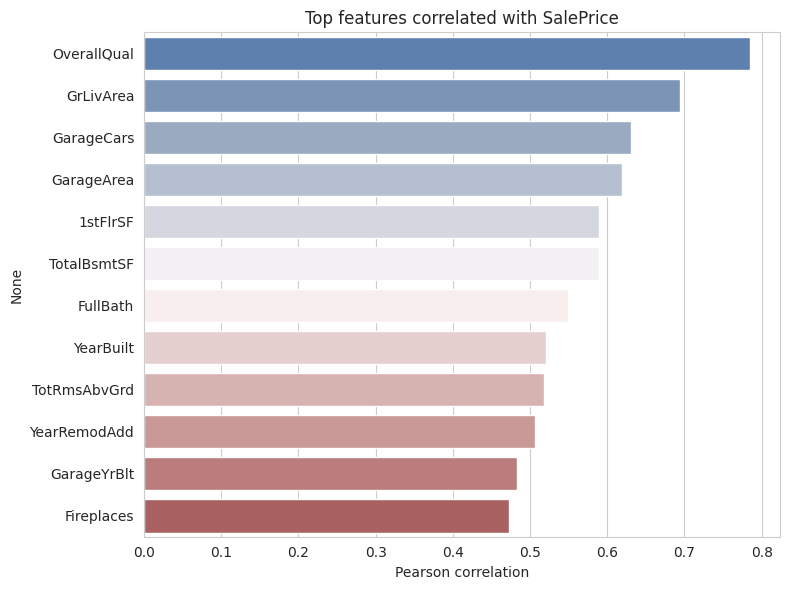

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
top_features = corr_target.abs().sort_values(ascending=False).head(12).index
sns.barplot(x=corr_target[top_features].values, y=top_features, ax=ax, palette='vlag')
ax.set_title('Top features correlated with SalePrice')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()


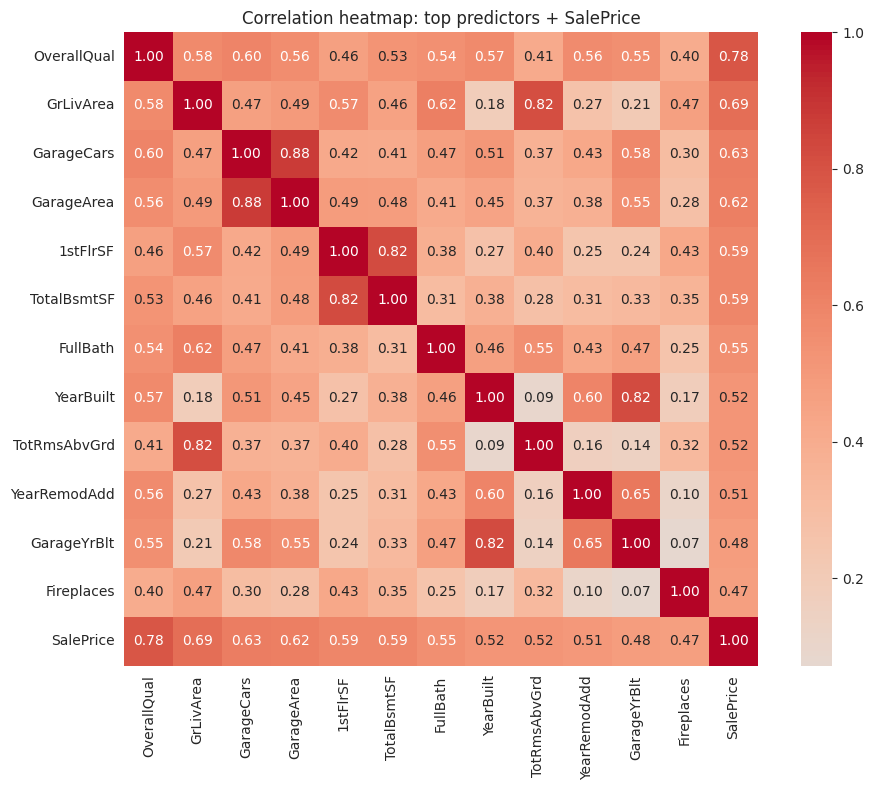

In [21]:
# Full correlation heatmap for the top correlated numeric features (to spot multicollinearity)
top_corr_cols = corr_target.abs().sort_values(ascending=False).head(12).index.tolist()
corr_matrix = df[top_corr_cols + ['SalePrice']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation heatmap: top predictors + SalePrice')
plt.tight_layout()
plt.show()


Notice pairs like `GarageCars` / `GarageArea` and `TotalBsmtSF` / `1stFlrSF` and `GrLivArea` /
`TotRmsAbvGrd`, which are strongly correlated **with each other**, not just with the target. For
regularized/linear models this multicollinearity inflates coefficient variance — consider dropping
one of each redundant pair, using PCA, or relying on Ridge/Lasso regularization (or just using a
tree-based model, which handles this natively).


## 6. Categorical Features

We check cardinality (number of unique categories — high cardinality means one-hot encoding will create
many sparse columns) and how the target varies across categories for the most relevant ones.


In [22]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist() + NUMERIC_BUT_CATEGORICAL
print(f"{len(categorical_cols)} categorical features")

cardinality = df[categorical_cols].nunique().sort_values(ascending=False)
cardinality.to_frame('n_unique')


44 categorical features


/tmp/ipykernel_521/3418680429.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist() + NUMERIC_BUT_CATEGORICAL


,n_unique
Neighborhood,25
MSSubClass,15
Exterior2nd,14
Exterior1st,13
SaleType,9
Condition1,9
Condition2,8
HouseStyle,8
Functional,7
RoofMatl,7


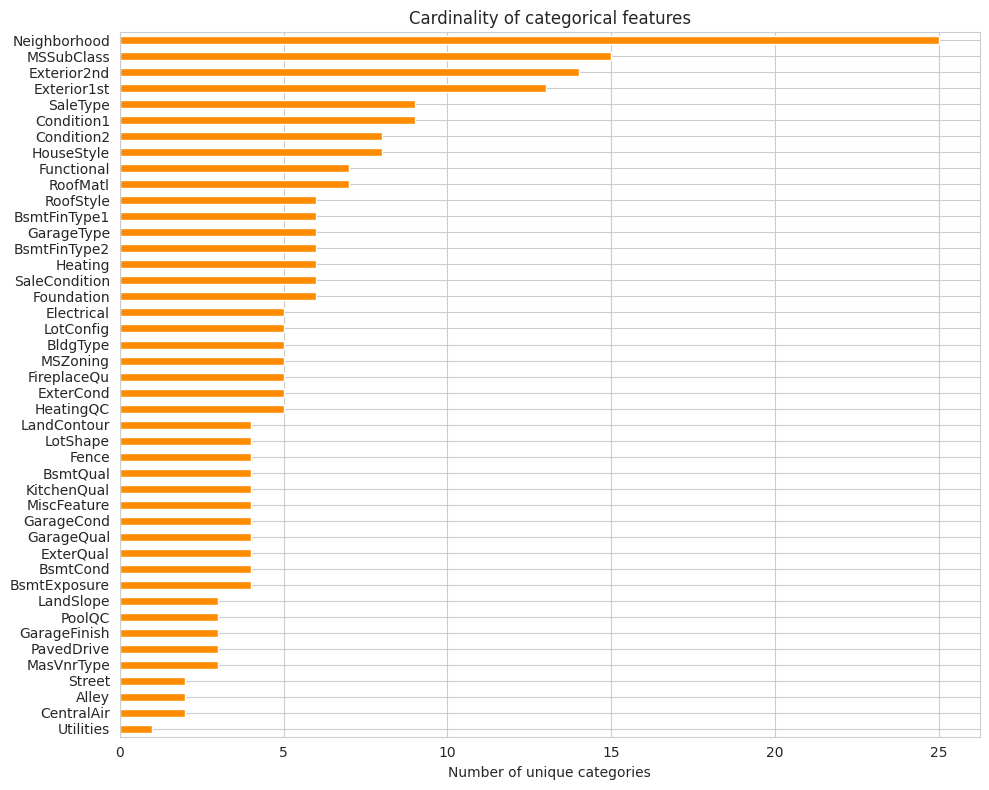

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
cardinality.plot(kind='barh', ax=ax, color='darkorange')
ax.invert_yaxis()
ax.set_xlabel('Number of unique categories')
ax.set_title('Cardinality of categorical features')
plt.tight_layout()
plt.show()


`Neighborhood`, `Exterior1st`/`Exterior2nd` have the highest cardinality (~15-25 categories).
One-hot encoding all of them is fine for tree models but will noticeably widen the feature matrix
for linear models — target encoding or grouping rare categories is a reasonable alternative.


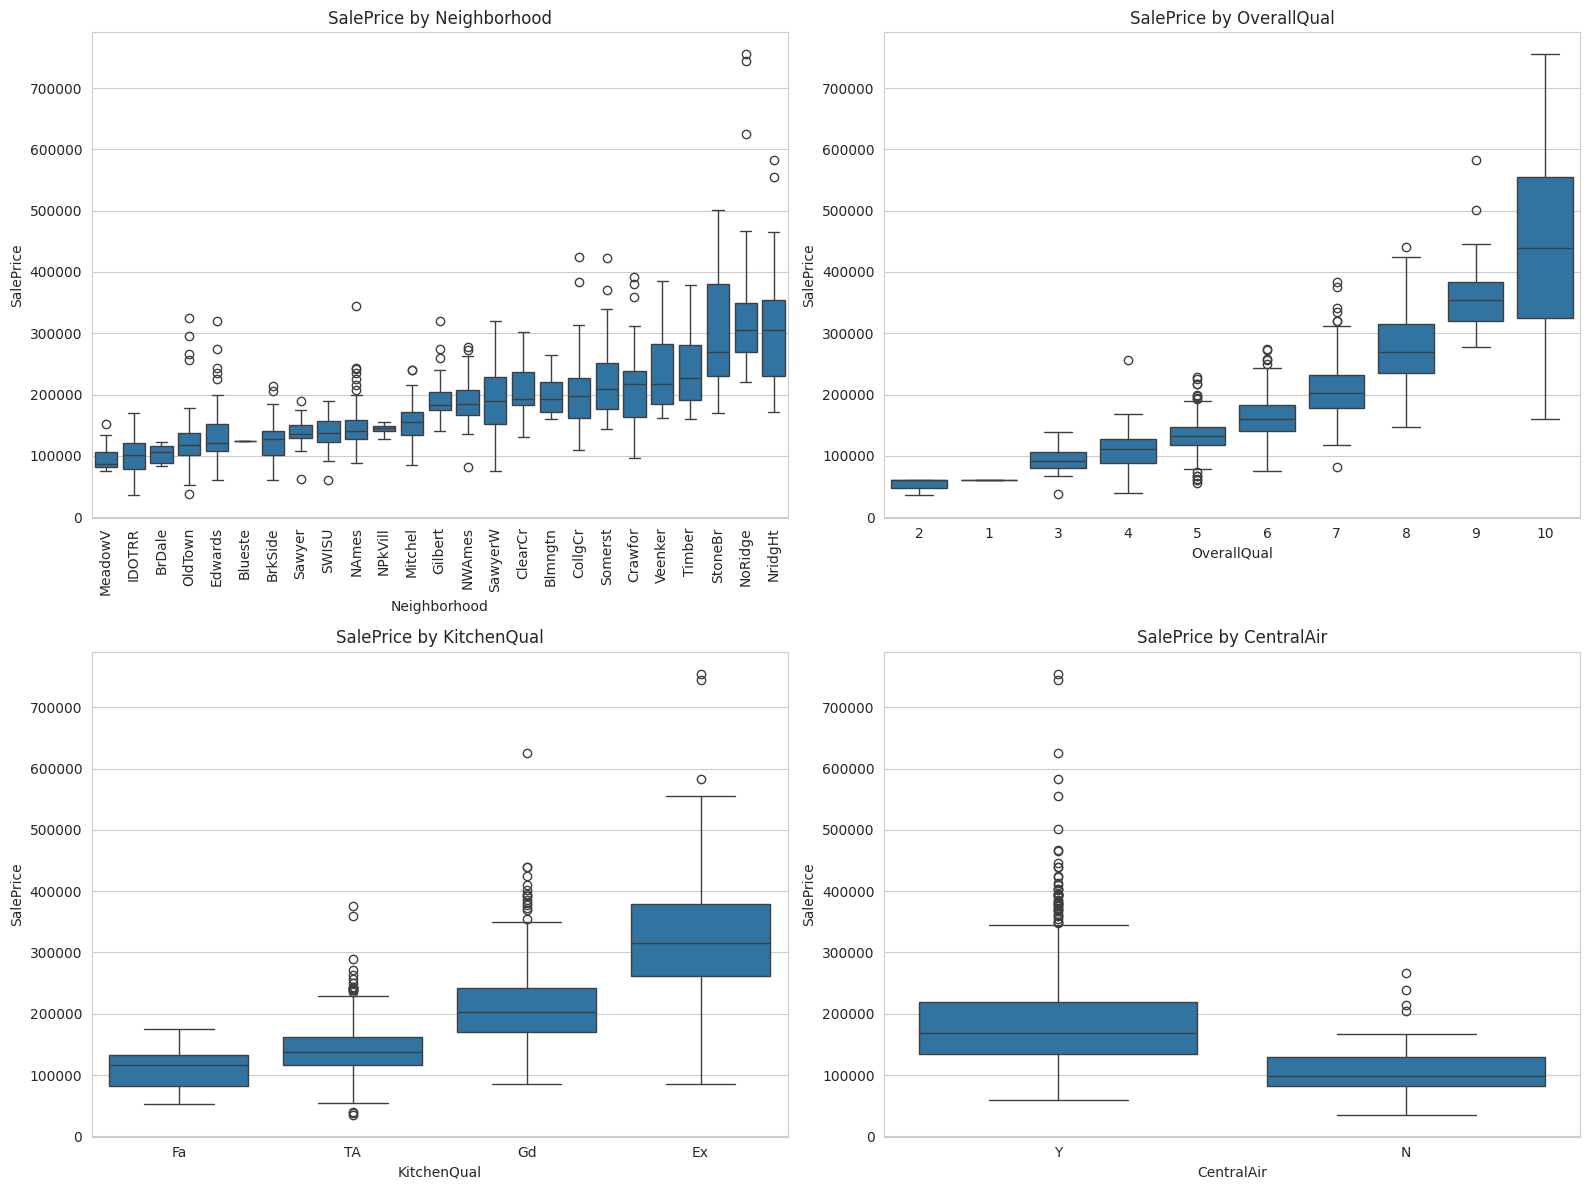

In [24]:
# Relationship between a few key categorical features and SalePrice
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order, ax=axes[0, 0])
axes[0, 0].tick_params(axis='x', rotation=90)
axes[0, 0].set_title('SalePrice by Neighborhood')

order = df.groupby('OverallQual')['SalePrice'].median().sort_values().index
sns.boxplot(data=df, x='OverallQual', y='SalePrice', order=order, ax=axes[0, 1])
axes[0, 1].set_title('SalePrice by OverallQual')

sns.boxplot(data=df, x='KitchenQual', y='SalePrice',
            order=['Fa', 'TA', 'Gd', 'Ex'], ax=axes[1, 0])
axes[1, 0].set_title('SalePrice by KitchenQual')

sns.boxplot(data=df, x='CentralAir', y='SalePrice', ax=axes[1, 1])
axes[1, 1].set_title('SalePrice by CentralAir')

plt.tight_layout()
plt.show()


`Neighborhood` and quality-related ordinal features (`OverallQual`, `KitchenQual`) show a strong,
monotonic relationship with price — these will be valuable predictors. Note several of these
"categorical" columns (`ExterQual`, `KitchenQual`, `BsmtQual`, etc.) are actually **ordinal** —
mapping them to integers (Po=1, Fa=2, TA=3, Gd=4, Ex=5) preserves the ordering, which is usually
better than one-hot encoding for these.


## 7. Outlier Detection

Ames Housing is known to contain a few extreme outliers (very large houses sold cheaply) that are
commonly recommended for removal in modeling guides for this dataset. We check `GrLivArea` vs
`SalePrice`, the classic example, plus a general IQR-based scan.


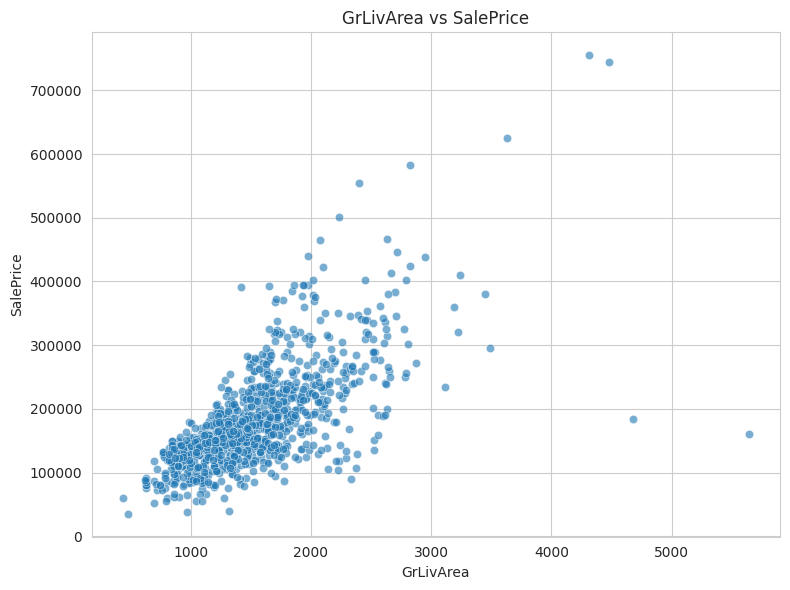

Suspected outliers (large GrLivArea, low SalePrice): 2


,Id,GrLivArea,SalePrice,OverallQual,SaleCondition
450,100365,5642,160000,10,Partial
820,100219,4676,184750,10,Partial


In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', ax=ax, alpha=0.6)
ax.set_title('GrLivArea vs SalePrice')
plt.tight_layout()
plt.show()

# Classic Ames outliers: very large living area but abnormally low price
suspects = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print(f"Suspected outliers (large GrLivArea, low SalePrice): {len(suspects)}")
suspects[['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'SaleCondition']]


In [26]:
# General IQR-based outlier scan across key numeric features
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = {col: iqr_outlier_count(df[col]) for col in key_numeric}
pd.Series(outlier_counts, name='n_outliers_iqr').sort_values(ascending=False).to_frame()


,n_outliers_iqr
GarageArea,68
LotArea,48
TotalBsmtSF,40
GrLivArea,20
TotRmsAbvGrd,18
1stFlrSF,16
YearBuilt,5
OverallQual,1


**Recommendation:** investigate/remove the 1-2 extreme `GrLivArea` outliers with disproportionately
low `SalePrice` (these are known data quality anomalies in Ames Housing, often partial sales), but be
conservative with IQR-based removal elsewhere — many "outliers" here (e.g. large `LotArea`) are
legitimate large properties, not data errors. Tree-based models are robust to these regardless.


## 8. Summary & Preprocessing Recommendations

| Aspect | Finding | Recommended action |
|---|---|---|
| **Target (`SalePrice`)** | Right-skewed, not normal (Shapiro rejects normality) | Model `log1p(SalePrice)`; invert with `expm1` for evaluation/reporting |
| **Missing values** | Mostly *meaningful* NAs (no pool/garage/basement/etc.), not random | Impute categoricals with `"None"`, related numerics with `0`; use group-median for `LotFrontage`; mode for `Electrical` |
| **Numeric scale** | Huge range disparity (e.g. `LotArea` vs `OverallQual`) | `StandardScaler`/`RobustScaler` for linear/distance-based models; not required for tree-based models |
| **Numeric skew** | Several highly skewed continuous features (areas) | `log1p` transform on continuous skewed features; binary indicators for sparse "mostly-zero" features (pool, misc, porches) |
| **Pseudo-numeric column** | `MSSubClass` is a nominal code, not a quantity | Treat as categorical (one-hot or target encoding), not as a numeric feature |
| **Ordinal categoricals** | Quality/condition fields (`ExterQual`, `KitchenQual`, `BsmtQual`, ...) have a natural order | Map to integers (ordinal encoding) rather than one-hot |
| **High-cardinality categoricals** | `Neighborhood`, `Exterior1st/2nd` | One-hot (fine for trees) or target/frequency encoding (better for linear models) |
| **Multicollinearity** | `GarageCars`/`GarageArea`, `TotalBsmtSF`/`1stFlrSF`, `GrLivArea`/`TotRmsAbvGrd` | Drop redundant one of each pair for linear models, or rely on Ridge/Lasso/tree models |
| **Outliers** | A few large-`GrLivArea`, low-price anomalies | Remove the 1-2 clear anomalies; keep the rest |

**Next steps:** build a `ColumnTransformer`-based pipeline implementing the above (impute -> encode ->
scale/transform), then validate model performance with cross-validation before/after each treatment
to confirm it actually improves generalization.
